In [1]:
import sklearn as sk
import numpy as np
import scanpy as sc
import scipy
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold


In [2]:
#!pip install -e /Users/annisa/Documents/G4/SCALES/spipy-main
import spipy as sp


In [ ]:
adata = sc.read_h5ad("/Users/annisa/Box Sync/G7/scales_run_ipynb/anc_nova_CRSCfiltered.h5ad")
adata.shape
# shuffle per condition (dataset)
adata.obs['shuffled'] = np.random.randint(0, 2, size=len(adata))

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.raw = adata          # ← SCALES reads from here
# everything below is only for UMAP/visualization, NOT for SCALES
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, n_comps=1000, svd_solver='arpack')

/Users/annisa/micromamba/envs/scales/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/annisa/micromamba/envs/scales/lib/python3.11/functools.py:909: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


In [5]:
adata.obs.value_counts('condition')

condition
anc_ypd-kcl-h2o2    5440
anc_ypd-sorb        4236
anc_sdc-kcl-h2o2    3844
anc_ypeg-30         3659
anc_sceg-30         3353
anc_sdc-kcl-diam    3191
anc_sdc-sorb        3123
anc_ypd-h2o2        2862
anc_ypd-kcl         2846
anc_ypd             2844
anc_sdc-h2o2        2813
anc_sdc-37          2760
anc_sdc-kcl         2756
anc_ypd-kcl-diam    2641
anc_sdc             2313
anc_ypeg-37         2260
anc_sceg-37         2211
anc_sdc-diam        2056
anc_ypd-37          1534
anc_ypd-diam         404
Name: count, dtype: int64

In [6]:
adata.obs

,rich_media,synthetic_media,30c,37c,dglucose,glyetoh,ros,h2o2,diamide,osmolytes,...,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,n_genes,n_counts,shuffled
anc_sceg-30_AAACCCAAGGTAGTAT-1,0,1,1,0,0,1,0,0,0,0,...,31.968504,47.559055,63.307087,100.000000,0.0,0.000000,0.000000,433,635.0,1
anc_sceg-30_AAACCCACAGAATGTA-1,0,1,1,0,0,1,0,0,0,0,...,21.966414,31.527627,45.232936,67.118093,0.0,0.000000,0.000000,1558,3692.0,0
anc_sceg-30_AAACGAAAGGTCGTGA-1,0,1,1,0,0,1,0,0,0,0,...,22.937905,34.476367,49.953661,73.540315,0.0,0.000000,0.000000,1071,2158.0,0
anc_sceg-30_AAACGAAGTAGTGGCA-1,0,1,1,0,0,1,0,0,0,0,...,27.059685,38.447455,53.057488,75.247162,0.0,0.000000,0.000000,1176,2731.0,1
anc_sceg-30_AAACGCTGTAGACGGT-1,0,1,1,0,0,1,0,0,0,0,...,32.261768,43.857635,58.897819,93.340987,0.0,0.000000,0.000000,558,871.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
anc_ypeg-37_TTTGGTTTCATCGACA-1,1,0,0,1,0,1,0,0,0,0,...,29.217200,40.242558,53.031974,86.108049,0.0,0.000000,0.000000,626,907.0,1
anc_ypeg-37_TTTGTTGAGAGCATTA-1,1,0,0,1,0,1,0,0,0,0,...,26.752221,37.084567,50.871997,71.997368,0.0,0.000000,0.000000,1351,3039.0,1
anc_ypeg-37_TTTGTTGCACTAAACC-1,1,0,0,1,0,1,0,0,0,0,...,32.900433,43.722944,55.735931,88.203463,1.0,0.693147,0.108225,609,924.0,1
anc_ypeg-37_TTTGTTGCAGGAGGTT-1,1,0,0,1,0,1,0,0,0,0,...,33.607306,42.739726,56.621005,84.018265,1.0,0.693147,0.091324,675,1095.0,1


In [7]:
skf = StratifiedKFold(n_splits=6, random_state=12345, shuffle=True)
n_samples = adata.shape[0] #number of cells
folds = skf.split(np.zeros(n_samples), np.zeros(n_samples))
adata.obs["fold_id"] = 0
for i, (train_index, test_index) in  enumerate(folds):  #_ is convention if I need to decouple tuples but I'm not using it in the loop
    adata.obs["fold_id"][test_index] = i  #creates a generator, can iterate over to generate indices to subset adata later

/var/folders/_m/0k5_0_vn1s94zhjd_fnjv43w0000gn/T/ipykernel_6976/2485457890.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  adata.obs["fold_id"][test_index] = i  #creates a generator, can iterate over to generate indices to subset adata l

In [8]:
adata.obs["fold_id"]
#unique, sort 

anc_sceg-30_AAACCCAAGGTAGTAT-1    1
anc_sceg-30_AAACCCACAGAATGTA-1    3
anc_sceg-30_AAACGAAAGGTCGTGA-1    3
anc_sceg-30_AAACGAAGTAGTGGCA-1    1
anc_sceg-30_AAACGCTGTAGACGGT-1    1
                                 ..
anc_ypeg-37_TTTGGTTTCATCGACA-1    4
anc_ypeg-37_TTTGTTGAGAGCATTA-1    2
anc_ypeg-37_TTTGTTGCACTAAACC-1    0
anc_ypeg-37_TTTGTTGCAGGAGGTT-1    1
anc_ypeg-37_TTTGTTGTCAACCCGG-1    2
Name: fold_id, Length: 57146, dtype: int64

In [9]:
adata_fold0 = adata[adata.obs["fold_id"] == 0]
adata0 = adata_fold0.raw.X.todense()
adata_fold1 = adata[adata.obs["fold_id"] == 1]
adata1 = adata_fold1.raw.X.todense()
adata_fold2 = adata[adata.obs["fold_id"] == 2]
adata2 = adata_fold2.raw.X.todense()
adata_fold3 = adata[adata.obs["fold_id"] == 3]
adata3 = adata_fold3.raw.X.todense()
adata_fold4 = adata[adata.obs["fold_id"] == 4]
adata4 = adata_fold4.raw.X.todense()
adata_fold5 = adata[adata.obs["fold_id"] == 5]
adata5 = adata_fold5.raw.X.todense()

In [10]:
u0, s0, vt0 = np.linalg.svd(adata0)
u1, s1, vt1 = np.linalg.svd(adata1)
u2, s2, vt2 = np.linalg.svd(adata2)
u3, s3, vt3 = np.linalg.svd(adata3)
u4, s4, vt4 = np.linalg.svd(adata4)
u5, s5, vt5 = np.linalg.svd(adata5)

In [11]:
u0.shape

(9525, 9525)

In [ ]:
s_mean = []
s_std = []
lower_bound = []
upper_bound = []
num_s = range(0, len(s0)-1)
for i in num_s:
    s_mean.append(np.mean([s0[i], s1[i], s2[i], s3[i], s4[i], s5[i]]))
    s_std.append(np.std([s0[i], s1[i], s2[i], s3[i], s4[i], s5[i]]))
    lower_bound.append(s_mean[i]-s_std[i])
    upper_bound.append(s_mean[i]+s_std[i])
s_mean

In [13]:
n_window = 3
channels = u0.shape[0] - n_window
metadata = pd.read_csv('/Users/annisa/Box Sync/G7/scales_run_ipynb/ConditionsMatrixCombined.csv', index_col=0)
env_list = list(metadata.columns)
env_list_short = ['rich_media', '30c', 'dglucose', 'ros', 'osmolytes', 'shuffled']

output0 = pd.DataFrame(0, index = range(u0.shape[0]-n_window), columns=env_list_short)
output1 = pd.DataFrame(0, index = range(u1.shape[0]-n_window), columns=env_list_short)
output2 = pd.DataFrame(0, index = range(u2.shape[0]-n_window), columns=env_list_short)
output3 = pd.DataFrame(0, index = range(u3.shape[0]-n_window), columns=env_list_short)
output4 = pd.DataFrame(0, index = range(u4.shape[0]-n_window), columns=env_list_short)
output5 = pd.DataFrame(0, index = range(u5.shape[0]-n_window), columns=env_list_short)

In [14]:

list_folds = [adata_fold0, adata_fold1, adata_fold2, adata_fold3, adata_fold4, adata_fold5]
outputs = [output0, output1, output2, output3, output4, output5]
list_u = [u0, u1, u2, u3, u4, u5]
list_s = [s0, s1, s2, s3, s4, s5]

In [15]:
range(channels)

range(0, 9522)

In [16]:
#output0 = pd.DataFrame(0, index = range(u0.shape[0]-n_window), columns=env_list_short)
#output1 = pd.DataFrame(0, index = range(u1.shape[0]-n_window), columns=env_list_short)

In [17]:
from scipy.spatial.distance import squareform
adata_fold1.obs['30c'].values[:, None] 

array([[1],
       [1],
       [1],
       ...,
       [0],
       [0],
       [0]], shape=(9525, 1))

In [18]:
#n_window=3
#for i in range(1, 50):
#        u_corr = sp.calc_spcorr_mtx(u1, s1, range(i,i+n_window))
#        u_corr_squareform = squareform(u_corr, checks=False)
#        print(len(u_corr_squareform))
#        for env in env_list_short:
#            env_corr = squareform(adata_fold1.obs[env].values[:, None] == adata_fold1.obs[env].values, checks=False)
#            print(len(env_corr))
#            output1.loc[i, env] = sp.empiricalMI_masked(u_corr_squareform, env_corr)

In [ ]:
#for fold in range(len(list_folds)):
n_window=3
for fold in range(6):
    for i in range(40):
        u_corr = sp.calc_spcorr_mtx(list_u[fold], list_s[fold], range(i,i+n_window))
        u_corr_squareform = squareform(u_corr, checks=False)
        print(i)
        for env in env_list_short:
            env_corr = squareform(list_folds[fold].obs[env].values[:, None] == list_folds[fold].obs[env].values, checks=False)
            outputs[fold].loc[i, env] = sp.empiricalMI_masked(u_corr_squareform, env_corr)



In [ ]:
n_window=3
for fold in range(6):
    for i in range(25):
        u_corr = sp.calc_spcorr_mtx(list_u[fold], list_s[fold], range(i,i+n_window))
        u_corr_squareform = squareform(u_corr, checks=False)
        print(i)
        env_corr = squareform(list_folds[fold].obs["shuffled"].values[:, None] == list_folds[fold].obs["shuffled"].values, checks=False)
        outputs[fold].loc[i, "shuffled"] = sp.empiricalMI_masked(u_corr_squareform, env_corr)



In [21]:
# Add a row of zeros at the beginning of each DataFrame
def add_zero_row(df):
    zero_row = pd.DataFrame([0] * df.shape[1]).T  # Create a row of zeros
    zero_row.columns = df.columns  # Match the column names
    return pd.concat([zero_row, df], axis=0).reset_index(drop=True)

# Apply to all cumulative_mi_unscaled DataFrames
cumulative_mi_unscaled0 = add_zero_row(output0.cumsum(axis=0))
cumulative_mi_unscaled1 = add_zero_row(output1.cumsum(axis=0))
cumulative_mi_unscaled2 = add_zero_row(output2.cumsum(axis=0))
cumulative_mi_unscaled3 = add_zero_row(output3.cumsum(axis=0))
cumulative_mi_unscaled4 = add_zero_row(output4.cumsum(axis=0))
cumulative_mi_unscaled5 = add_zero_row(output5.cumsum(axis=0))

In [22]:
outputs[2]

,rich_media,30c,dglucose,ros,osmolytes,shuffled
0,0.008572,0.005388,0.150172,0.000451,0.034438,6.163068e-07
1,0.001263,0.003112,0.063997,0.004571,0.024965,1.079902e-06
2,0.005221,0.004823,0.012082,0.009989,0.005930,1.314925e-06
3,0.116001,0.002449,0.001276,0.005775,0.001951,1.158350e-06
4,0.071509,0.000300,0.005933,0.000932,0.001237,1.246354e-06
...,...,...,...,...,...,...
9516,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9518,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [23]:
output0

,rich_media,30c,dglucose,ros,osmolytes,shuffled
0,0.002087,0.009455,0.021519,0.003371,0.010652,1.244027e-06
1,0.002068,0.001048,0.003177,0.001303,0.008353,9.346935e-07
2,0.019750,0.001143,0.006099,0.006343,0.011545,9.895169e-07
3,0.042854,0.002416,0.000552,0.005970,0.007904,1.408025e-06
4,0.056167,0.000478,0.004880,0.000569,0.006017,1.256359e-06
...,...,...,...,...,...,...
9517,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9518,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9519,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00
9520,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00


In [24]:
cumulative_mi_unscaled0

,rich_media,30c,dglucose,ros,osmolytes,shuffled
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.002087,0.009455,0.021519,0.003371,0.010652,0.000001
2,0.004155,0.010504,0.024696,0.004673,0.019005,0.000002
3,0.023906,0.011647,0.030795,0.011017,0.030550,0.000003
4,0.066760,0.014063,0.031347,0.016987,0.038454,0.000005
...,...,...,...,...,...,...
9518,0.125708,0.021512,0.046852,0.022904,0.089739,0.000044
9519,0.125708,0.021512,0.046852,0.022904,0.089739,0.000044
9520,0.125708,0.021512,0.046852,0.022904,0.089739,0.000044
9521,0.125708,0.021512,0.046852,0.022904,0.089739,0.000044


In [25]:
import seaborn as sns
%config InlineBackend.figure_formats = ['svg'] #i want vector graphics
%matplotlib inline 
import matplotlib.pyplot as plt
# sns.set_theme(style="white")
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(style="white", rc=custom_params)

In [27]:
cumulative_mi0= cumulative_mi_unscaled0.loc[0:40]/cumulative_mi_unscaled0.loc[40]
cumulative_mi1= cumulative_mi_unscaled1.loc[0:40]/cumulative_mi_unscaled1.loc[40]
cumulative_mi2= cumulative_mi_unscaled2.loc[0:40]/cumulative_mi_unscaled2.loc[40]
cumulative_mi3= cumulative_mi_unscaled3.loc[0:40]/cumulative_mi_unscaled3.loc[40]
cumulative_mi4= cumulative_mi_unscaled4.loc[0:40]/cumulative_mi_unscaled4.loc[40]
cumulative_mi5= cumulative_mi_unscaled5.loc[0:40]/cumulative_mi_unscaled5.loc[40]

(0.0, 25.0)

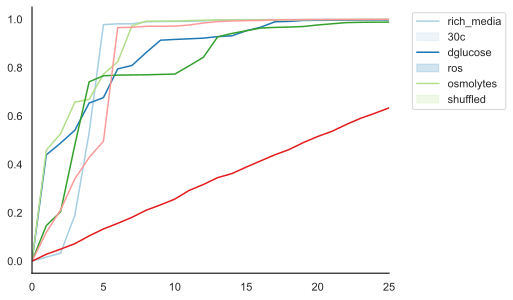

In [28]:
fig = plt.figure()
sns.set_palette("Paired", 13)
for env in cumulative_mi0.columns:
    ax1 = sns.lineplot(x=cumulative_mi0.index.values, y = cumulative_mi0[env].values)
    #ax.legend(env)
plt.legend(cumulative_mi0.columns, bbox_to_anchor=(1.05,1), loc='upper left')
plt.xlim(0,25)

(0.0, 25.0)

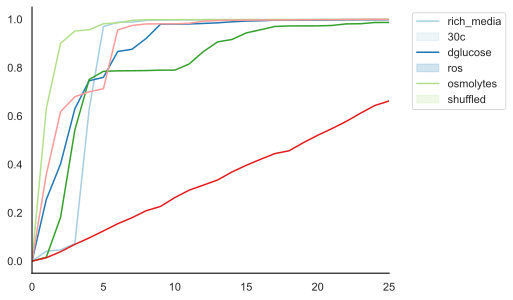

In [29]:
fig = plt.figure()
sns.set_palette("Paired", 13)
for env in cumulative_mi2.columns:
    ax1 = sns.lineplot(x=cumulative_mi2.index.values, y = cumulative_mi2[env].values)
    #ax.legend(env)
plt.legend(cumulative_mi2.columns, bbox_to_anchor=(1.05,1), loc='upper left')
plt.xlim(0,25)

In [30]:
dfs =[cumulative_mi1,cumulative_mi2,cumulative_mi3,cumulative_mi4,cumulative_mi5]
df_concat = pd.concat(dfs)
mean_cum_mi = df_concat.stack().groupby(level=[0,1]).mean().unstack()
std_cum_mi = df_concat.stack().groupby(level=[0,1]).std().unstack()
ste_cum_mi = std_cum_mi/6

In [31]:
ste_cum_mi

,30c,dglucose,osmolytes,rich_media,ros,shuffled
0,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000
1,0.008941,3.273506e-02,0.014311,3.669123e-03,0.009464,0.002213
2,0.013468,2.216325e-02,0.015901,2.525832e-03,0.019925,0.001769
3,0.008290,8.639034e-03,0.018077,3.031754e-02,0.013936,0.001561
4,0.007210,8.929319e-03,0.013703,2.781241e-02,0.009928,0.002076
5,0.007446,5.264215e-03,0.012038,2.016332e-03,0.010402,0.002387
6,0.013430,9.483898e-04,0.008347,4.696231e-04,0.010245,0.002639
7,0.010651,1.013632e-03,0.006023,4.613167e-04,0.009979,0.002608
8,0.004619,9.627773e-04,0.004532,3.480261e-04,0.009816,0.002860
9,0.004789,1.881760e-04,0.004380,3.646919e-04,0.009955,0.003372


(0.0, 1.0)

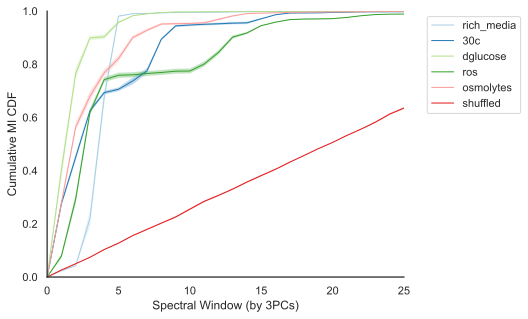

In [33]:
fig = plt.figure()
sns.set_palette("Paired", 13)
line_handles = []
env_list_plot = [env for env in env_list_short if env != 'shuffle']
for env in env_list_plot:
    ax1 = sns.lineplot(x=mean_cum_mi.index.values, y=mean_cum_mi[env].values, linewidth=1)
    lower_bound = mean_cum_mi[env].values - ste_cum_mi[env].values
    upper_bound = mean_cum_mi[env].values + ste_cum_mi[env].values
    plt.fill_between(mean_cum_mi.index.values, lower_bound, upper_bound, alpha=.3)
    line_handles.append(ax1.lines[-1])  # grab the line just drawn

plt.xlabel("Spectral Window (by 3PCs)")
plt.ylabel("Cumulative MI CDF")
plt.legend(line_handles, env_list_short, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 25)  # start at 1 instead of 0
plt.ylim(0, 1)

In [ ]:
mean_cum_mi.to_csv("anc_micdf_with_shuffle")
ste_cum_mi.to_csv("anc_micdf_stderr_w_shuffle")